Loading dataset ...
Total Rows : 2723
Tech Roles : 8


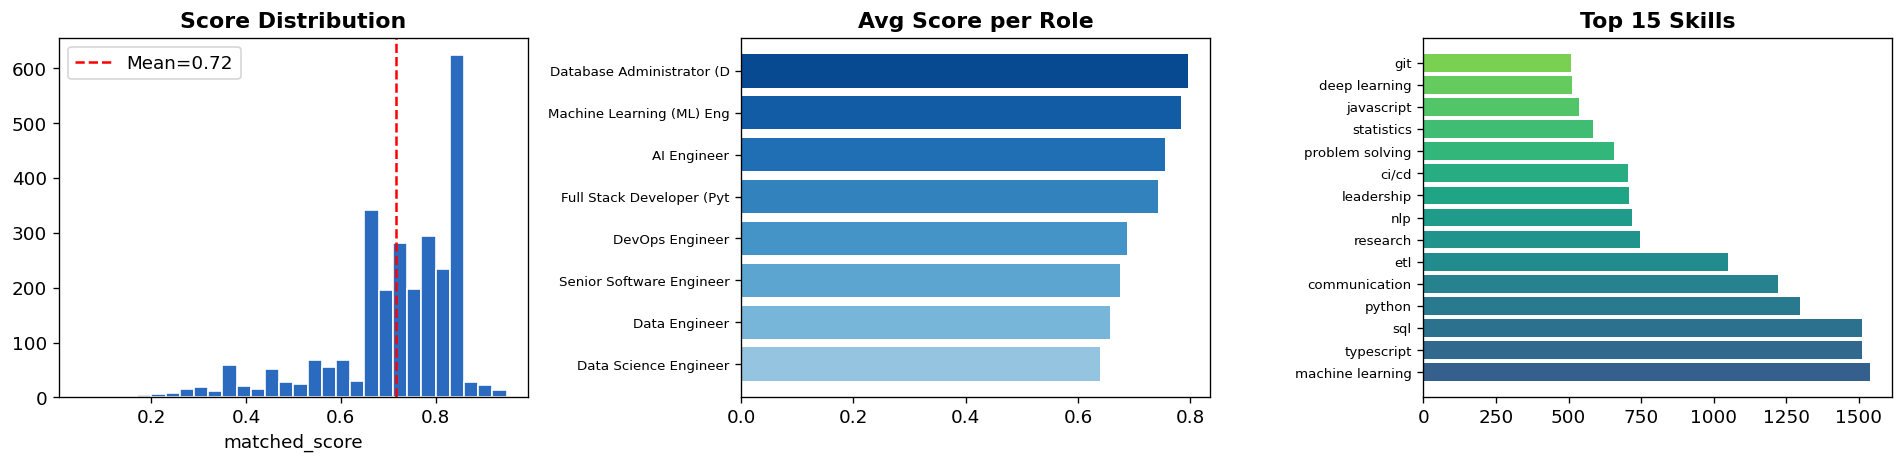

Fitting TF-IDF ...
Vocabulary size: 10,000
Building feature matrix ...
Feature matrix shape: (2723, 14)
Training model ...
RMSE : 0.1229
R²   : 0.2945


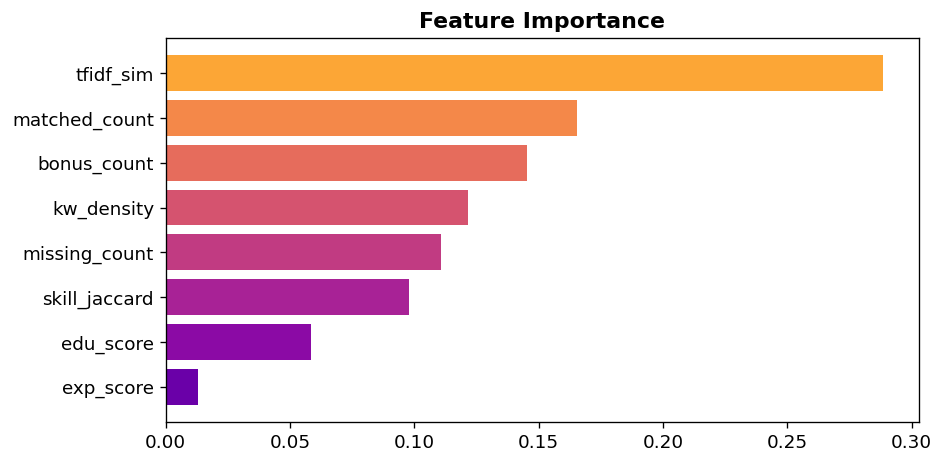


Ranking candidates for: AI Engineer
  RANKING  —  AI ENGINEER
  #01  Candidate_063   85.7/100  █████████████████░░░
       Matched : ['communication', 'java', 'machine learning', 'problem solving', 'python']
       Missing : ['pytorch', 'scikit-learn', 'tensorflow']
       Exp     : 0 yr(s)

  #02  Candidate_100   85.4/100  █████████████████░░░
       Matched : ['communication', 'machine learning', 'problem solving', 'python']
       Missing : ['java', 'pytorch', 'scikit-learn', 'tensorflow']
       Exp     : 3 yr(s)

  #03  Candidate_029   85.0/100  ████████████████░░░░
       Matched : ['communication', 'java', 'machine learning', 'problem solving', 'python']
       Missing : ['pytorch', 'scikit-learn', 'tensorflow']
       Exp     : 2 yr(s)

  #04  Candidate_329   84.9/100  ████████████████░░░░
       Matched : ['communication', 'java', 'machine learning', 'problem solving', 'python']
       Missing : ['pytorch', 'scikit-learn', 'tensorflow']
       Exp     : 12 yr(s)

  #05  Candi

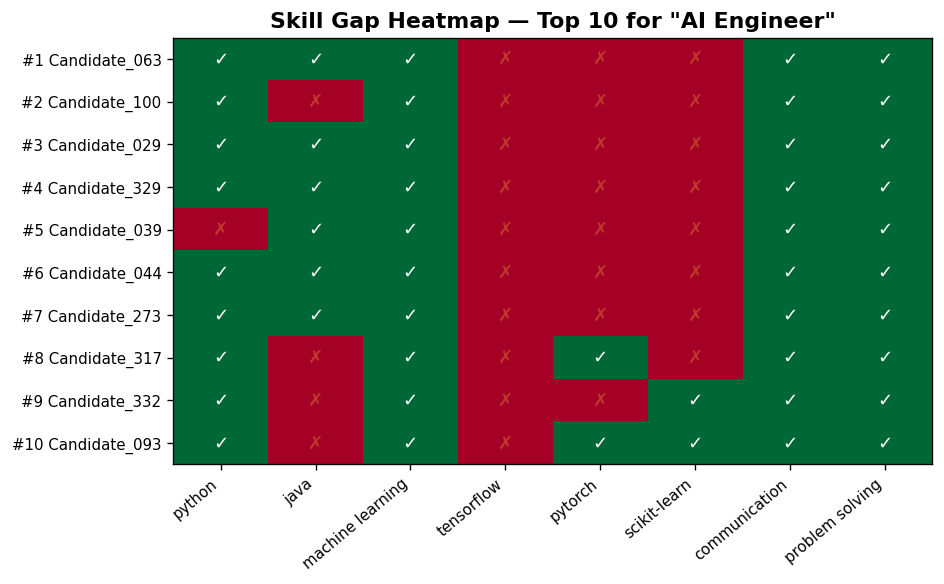


✅ Done!


In [1]:
import re, ast, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ─── CONFIG ───────────────────────────────────────────────────
CSV_PATH = r'C:\Users\anusha\Documents\task3\resume_data.csv'  # ← change this
ROLE     = 'AI Engineer'                     # ← change this

TECH_ROLES = [
    'AI Engineer',
    'Machine Learning (ML) Engineer',
    'Data Engineer',
    'Data Science Engineer',
    'Senior Software Engineer',
    'DevOps Engineer',
    'Full Stack Developer (Python,React js)',
    'Database Administrator (DBA)',
]

FEATURE_COLS = [
    'tfidf_sim', 'skill_jaccard', 'matched_count',
    'missing_count', 'bonus_count', 'exp_score',
    'edu_score', 'kw_density'
]

SKILL_TAXONOMY = {
    'python':           ['python'],
    'javascript':       ['javascript', 'js'],
    'typescript':       ['typescript', 'ts'],
    'java':             ['java', 'core java'],
    'scala':            ['scala'],
    'go':               ['golang', ' go '],
    'c++':              ['c++', 'cpp'],
    'c#':               ['c#', 'csharp'],
    'sql':              ['sql', 'mysql', 'postgresql', 'sqlite'],
    'machine learning': ['machine learning', ' ml '],
    'deep learning':    ['deep learning', 'neural network', 'cnn', 'lstm'],
    'nlp':              ['nlp', 'natural language processing'],
    'computer vision':  ['computer vision', 'image recognition'],
    'tensorflow':       ['tensorflow', 'keras'],
    'pytorch':          ['pytorch'],
    'scikit-learn':     ['scikit-learn', 'sklearn'],
    'pandas':           ['pandas'],
    'numpy':            ['numpy'],
    'llm':              ['llm', 'large language model', 'gpt', 'bert'],
    'spark':            ['apache spark', 'pyspark'],
    'kafka':            ['kafka'],
    'airflow':          ['airflow'],
    'etl':              ['etl', 'elt', 'data pipeline'],
    'aws':              ['aws', 'amazon web services', 'sagemaker'],
    'azure':            ['azure', 'microsoft azure'],
    'gcp':              ['gcp', 'google cloud', 'bigquery'],
    'docker':           ['docker'],
    'kubernetes':       ['kubernetes', 'k8s'],
    'ci/cd':            ['ci/cd', 'github actions', 'jenkins'],
    'terraform':        ['terraform'],
    'git':              ['git', 'github', 'gitlab'],
    'mongodb':          ['mongodb'],
    'redis':            ['redis'],
    'elasticsearch':    ['elasticsearch'],
    'snowflake':        ['snowflake'],
    'react':            ['react', 'reactjs'],
    'django':           ['django'],
    'flask':            ['flask'],
    'fastapi':          ['fastapi'],
    'rest api':         ['rest api', 'restful'],
    'statistics':       ['statistics', 'statistical analysis'],
    'mathematics':      ['mathematics', 'linear algebra'],
    'research':         ['research', 'published'],
    'communication':    ['communication', 'presentation'],
    'leadership':       ['leadership', 'team lead', 'mentoring'],
    'agile':            ['agile', 'scrum', 'kanban'],
    'problem solving':  ['problem solving', 'analytical'],
}

EDU_WEIGHTS = {
    'phd': 1.0, 'ph.d': 1.0, 'doctorate': 1.0,
    'master': 0.8, 'msc': 0.8, 'mba': 0.8,
    'bachelor': 0.6, 'bsc': 0.6, 'b.e.': 0.6,
    'degree': 0.5, 'diploma': 0.4
}

STOP_WORDS = {
    "a","an","the","and","or","but","in","on","at","to","for","of","with",
    "by","from","is","are","was","were","be","been","have","has","had",
    "do","does","did","will","would","could","should","may","might","i",
    "we","you","he","she","it","they","my","our","your","his","her","its",
    "this","that","these","those","not","no","as","if","so","more","also"
}

# ─── HELPER FUNCTIONS ─────────────────────────────────────────
def clean_text(text):
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    text = re.sub(r'[^\w\s\+\#]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

def preprocess(text):
    tokens = [t for t in clean_text(text).split()
              if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)

def extract_skills(text):
    tl = text.lower()
    return [canon for canon, aliases in SKILL_TAXONOMY.items()
            if any(alias in tl for alias in aliases)]

def skill_overlap(resume_skills, jd_skills):
    r, j = set(resume_skills), set(jd_skills)
    return {
        'matched': sorted(r & j),
        'missing': sorted(j - r),
        'bonus':   sorted(r - j),
        'jaccard': len(r & j) / len(r | j) if (r | j) else 0.0
    }

def edu_score(text):
    tl = text.lower()
    return max((v for k, v in EDU_WEIGHTS.items() if k in tl), default=0.0)

def years_of_experience(text):
    patterns = [
        r'(\d+)\+?\s+years?\s+of\s+(?:professional\s+)?experience',
        r'(\d+)\+?\s+years?\s+(?:in|of|with)',
        r'experience\s+of\s+(\d+)\+?\s+years?'
    ]
    vals = []
    for p in patterns:
        for m in re.finditer(p, text.lower()):
            vals.append(float(m.group(1)))
    return max(vals) if vals else 0.0

def parse_required_years(text):
    m = re.search(r'(\d+)\+?\s*year', text.lower())
    return float(m.group(1)) if m else 0.0

def keyword_density(resume_text, jd_text):
    jd_tok  = set(preprocess(jd_text).split())
    res_tok = set(preprocess(resume_text).split())
    return len(jd_tok & res_tok) / max(len(jd_tok), 1)

def safe_list(val):
    if pd.isna(val): return []
    try:
        r = ast.literal_eval(str(val))
        return [str(x) for x in r if x and str(x) != 'None'] if isinstance(r, list) else [str(r)]
    except:
        return [str(val)]

def build_text(row, cols):
    return ' '.join(t for c in cols for t in safe_list(row.get(c, '')))

def batch_similarity(resume_texts, jd_text):
    jd_vec  = vectorizer.transform([preprocess(jd_text)])
    res_vec = vectorizer.transform([preprocess(t) for t in resume_texts])
    return cosine_similarity(res_vec, jd_vec).flatten()

# ─── LOAD DATA ────────────────────────────────────────────────
print('Loading dataset ...')
df_raw = pd.read_csv(CSV_PATH)
jd_col = [c for c in df_raw.columns if 'job_position' in c][0]

RES_COLS = ['career_objective','skills','degree_names','positions',
            'responsibilities','related_skils_in_job',
            'major_field_of_studies','certification_skills']
JD_COLS  = ['skills_required','responsibilities.1',
            'educationaL_requirements','experiencere_requirement']

df_raw['resume_text'] = df_raw.apply(lambda r: build_text(r, RES_COLS), axis=1)
df_raw['jd_text']     = df_raw.apply(lambda r: build_text(r, JD_COLS),  axis=1)
df_raw['jd_name']     = df_raw[jd_col].fillna('Unknown')

df = df_raw[df_raw['jd_name'].isin(TECH_ROLES)].copy().reset_index(drop=True)
df['resume_skills'] = df['resume_text'].apply(extract_skills)
df['jd_skills']     = df['jd_text'].apply(extract_skills)

print(f'Total Rows : {len(df)}')
print(f'Tech Roles : {df["jd_name"].nunique()}')

# ─── EXPLORE CHARTS ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['matched_score'], bins=30, color='#2a6abf', edgecolor='white')
axes[0].axvline(df['matched_score'].mean(), color='red', lw=1.5,
                linestyle='--', label=f'Mean={df["matched_score"].mean():.2f}')
axes[0].set_title('Score Distribution', fontweight='bold')
axes[0].set_xlabel('matched_score')
axes[0].legend()

role_means = df.groupby('jd_name')['matched_score'].mean().sort_values()
axes[1].barh(range(len(role_means)), role_means.values,
             color=cm.Blues(np.linspace(0.4, 0.9, len(role_means))))
axes[1].set_yticks(range(len(role_means)))
axes[1].set_yticklabels([r[:25] for r in role_means.index], fontsize=8)
axes[1].set_title('Avg Score per Role', fontweight='bold')

all_skills = [s for skills in df['resume_skills'] for s in skills]
skill_freq = Counter(all_skills).most_common(15)
names, counts = zip(*skill_freq)
axes[2].barh(range(len(names)), counts,
             color=cm.viridis(np.linspace(0.3, 0.8, len(counts))))
axes[2].set_yticks(range(len(names)))
axes[2].set_yticklabels(names, fontsize=8)
axes[2].set_title('Top 15 Skills', fontweight='bold')

plt.tight_layout()
plt.show()

# ─── TF-IDF ───────────────────────────────────────────────────
print('Fitting TF-IDF ...')
corpus = df['resume_text'].tolist() + df['jd_text'].drop_duplicates().tolist()
vectorizer = TfidfVectorizer(
    max_features=10_000, ngram_range=(1, 2),
    sublinear_tf=True, strip_accents='unicode', stop_words='english'
)
vectorizer.fit([preprocess(t) for t in corpus])
print(f'Vocabulary size: {len(vectorizer.vocabulary_):,}')

# ─── FEATURE MATRIX ───────────────────────────────────────────
print('Building feature matrix ...')
records = []
for jd_text, grp in df.groupby('jd_text'):
    res_texts = grp['resume_text'].tolist()
    sims      = batch_similarity(res_texts, jd_text)
    jd_skills = extract_skills(jd_text)
    req_years = parse_required_years(jd_text)

    for i, (idx, row) in enumerate(grp.iterrows()):
        res_text   = row['resume_text']
        res_skills = extract_skills(res_text)
        gap        = skill_overlap(res_skills, jd_skills)
        exp        = years_of_experience(res_text)
        exp_sc     = min(exp / max(req_years, 1.0), 1.0) if req_years > 0 else min(exp / 5.0, 1.0)

        records.append({
            '_idx':          idx,
            'tfidf_sim':     sims[i],
            'skill_jaccard': gap['jaccard'],
            'matched_count': len(gap['matched']),
            'missing_count': len(gap['missing']),
            'bonus_count':   len(gap['bonus']),
            'exp_score':     exp_sc,
            'edu_score':     edu_score(res_text),
            'kw_density':    keyword_density(res_text, jd_text),
            '_matched':      gap['matched'],
            '_missing':      gap['missing'],
            '_bonus':        gap['bonus'],
            '_exp_years':    exp,
        })

feat_df = pd.DataFrame(records).set_index('_idx')
feat_df = feat_df.join(df[['matched_score', 'jd_name']])
feat_df.dropna(inplace=True)
print(f'Feature matrix shape: {feat_df.shape}')

# ─── TRAIN MODEL ──────────────────────────────────────────────
print('Training model ...')
X = feat_df[FEATURE_COLS]
y = feat_df['matched_score']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                   learning_rate=0.05, random_state=42)
model.fit(X_train_sc, y_train)

preds = model.predict(X_test_sc)
print(f'RMSE : {mean_squared_error(y_test, preds)**0.5:.4f}')
print(f'R²   : {r2_score(y_test, preds):.4f}')

# Feature importance chart
imp = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(range(len(imp)), imp.values,
        color=cm.plasma(np.linspace(0.2, 0.8, len(imp))))
ax.set_yticks(range(len(imp)))
ax.set_yticklabels(imp.index)
ax.set_title('Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

# ─── RANK CANDIDATES ──────────────────────────────────────────
print(f'\nRanking candidates for: {ROLE}')
role_df   = df[df['jd_name'] == ROLE].copy().reset_index(drop=True)
jd_text   = role_df['jd_text'].iloc[0]
jd_skills = extract_skills(jd_text)

records = []
for i, (_, row) in enumerate(role_df.iterrows()):
    res_text   = row['resume_text']
    res_skills = extract_skills(res_text)
    gap        = skill_overlap(res_skills, jd_skills)
    exp        = years_of_experience(res_text)
    req_years  = parse_required_years(jd_text)
    exp_sc     = min(exp / max(req_years, 1.0), 1.0) if req_years > 0 else min(exp / 5.0, 1.0)
    sim        = batch_similarity([res_text], jd_text)[0]

    records.append({
        'name':          f'Candidate_{i+1:03d}',
        'resume_text':   res_text,
        'tfidf_sim':     sim,
        'skill_jaccard': gap['jaccard'],
        'matched_count': len(gap['matched']),
        'missing_count': len(gap['missing']),
        'bonus_count':   len(gap['bonus']),
        'exp_score':     exp_sc,
        'edu_score':     edu_score(res_text),
        'kw_density':    keyword_density(res_text, jd_text),
        '_matched':      gap['matched'],
        '_missing':      gap['missing'],
        '_bonus':        gap['bonus'],
        '_exp_years':    exp,
    })

result_df = pd.DataFrame(records)
feat_sc   = scaler.transform(result_df[FEATURE_COLS])
preds     = np.clip(model.predict(feat_sc) * 100, 0, 100)

result_df['predicted_score'] = preds
result_df = result_df.sort_values('predicted_score', ascending=False).reset_index(drop=True)
result_df.insert(0, 'rank', range(1, len(result_df)+1))

# Print report
sep = '=' * 65
print(sep)
print(f'  RANKING  —  {ROLE.upper()}')
print(sep)
for _, r in result_df.head(10).iterrows():
    sc  = r['predicted_score']
    bar = '█' * int(sc/5) + '░' * (20 - int(sc/5))
    print(f"  #{int(r['rank']):02d}  {r['name']}  {sc:5.1f}/100  {bar}")
    print(f"       Matched : {r['_matched'] or ['none']}")
    print(f"       Missing : {r['_missing'] or ['none']}")
    print(f"       Exp     : {r['_exp_years']:.0f} yr(s)")
    print()
print(sep)

# ─── SKILL GAP HEATMAP ────────────────────────────────────────
top10 = result_df.head(10)
skill_matrix = []
for _, r in top10.iterrows():
    res_skills = extract_skills(r['resume_text'])
    skill_matrix.append([1 if s in res_skills else 0 for s in jd_skills])

skill_arr = np.array(skill_matrix)
labels    = [f"#{int(r['rank'])} {r['name']}" for _, r in top10.iterrows()]

fig, ax = plt.subplots(figsize=(max(8, len(jd_skills)), 5))
ax.imshow(skill_arr, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(jd_skills)))
ax.set_xticklabels(jd_skills, rotation=40, ha='right', fontsize=9)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_title(f'Skill Gap Heatmap — Top 10 for "{ROLE}"', fontweight='bold')

for i in range(len(labels)):
    for j in range(len(jd_skills)):
        ax.text(j, i, '✓' if skill_arr[i,j] else '✗',
                ha='center', va='center', fontsize=11,
                color='white' if skill_arr[i,j] else '#c0392b')

plt.tight_layout()
plt.show()

print('\n✅ Done!')